<a href="https://colab.research.google.com/github/jkk300000/PineScript-TradingView-_algorithmTradingSauce/blob/main/%ED%8A%B8%EB%A0%88%EC%9D%B4%EB%94%A9_%EB%B7%B0_%EC%95%8C%EA%B3%A0%EB%A6%AC%EC%A6%98_%EC%9E%90%EB%8F%99%EB%A7%A4%EB%A7%A4_%EC%88%98%EC%9D%B5%EB%A5%A0_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('/content/sample_data/내_전략_List_of_Trades_2025-01-27.csv')

In [3]:
data2 = pd.read_csv('/content/sample_data/내_전략_List_of_Trades_2025-01-27 (1).csv')

In [4]:
data3 = pd.read_csv('/content/sample_data/스퀴즈_모멘텀_비트코인_List_of_Trades_2025-01-27.csv')

In [5]:
import pandas as pd

def calculate_profit(data, initial_capital=1000, output_file="monthly_profit.xlsx"):
    # Remove the first two rows (if necessary)
    data = data.iloc[2:].reset_index(drop=True)

    # Extract relevant columns
    trade_data = data['거래 #']
    date_data = data['날짜/시간']
    profit_data = data['수익 USDT']

    # Concatenate into a new DataFrame
    concat_data = pd.DataFrame({
        '거래 #': trade_data,
        '날짜/시간': date_data,
        '수익 USDT': profit_data
    })

    # Drop duplicates based on '거래 #' column
    data_cleaned = concat_data.drop_duplicates(subset='거래 #', keep='first').copy()

    # Convert '날짜/시간' column to datetime, forcing errors to NaT (Not a Time) if conversion fails
    data_cleaned['날짜/시간'] = pd.to_datetime(data_cleaned['날짜/시간'], errors='coerce')

    # Drop rows with invalid dates
    data_cleaned = data_cleaned.dropna(subset=['날짜/시간'])

    # Extract Year and Month only after successful datetime conversion
    data_cleaned['Year'] = data_cleaned['날짜/시간'].dt.year
    data_cleaned['Month'] = data_cleaned['날짜/시간'].dt.month

    # Group by Year and Month and sum the profits
    monthly_price_sum = data_cleaned.groupby(['Year', 'Month'])['수익 USDT'].sum().reset_index()

    # Track capital and standalone profit percentage for each month
    capital = initial_capital
    monthly_price_sum['Standalone Profit'] = 0  # To store monthly profit independently
    monthly_price_sum['Standalone Profit %'] = 0  # To store monthly profit percentage
    monthly_price_sum['Cumulative Profit'] = 0
    monthly_price_sum['End Capital'] = 0
    monthly_price_sum['Profit % USDT'] = 0
    monthly_price_sum['Days in Month'] = 0  # Number of days in the month

    # Iterate to calculate standalone profit and capital
    for idx, row in monthly_price_sum.iterrows():
        # Calculate the standalone monthly profit
        standalone_profit = row['수익 USDT']

        # Calculate standalone profit percentage relative to the starting capital for the month
        standalone_profit_percentage = (standalone_profit / capital) * 100

        # Update cumulative profit and capital
        capital += standalone_profit
        monthly_price_sum.at[idx, 'Standalone Profit'] = standalone_profit
        monthly_price_sum.at[idx, 'Standalone Profit %'] = standalone_profit_percentage
        monthly_price_sum.at[idx, 'Cumulative Profit'] = capital - initial_capital
        monthly_price_sum.at[idx, 'End Capital'] = capital

        # Calculate the overall profit percentage based on initial capital
        monthly_price_sum.at[idx, 'Profit % USDT'] = (capital - initial_capital) / initial_capital * 100

        # Calculate the number of days in the month
        last_day_of_month = pd.to_datetime(f'{int(row["Year"])}-{int(row["Month"]):02d}-01') + pd.offsets.MonthEnd(1)
        monthly_price_sum.at[idx, 'Days in Month'] = last_day_of_month.day

    # Export the result to an Excel file
    monthly_price_sum.to_excel(output_file, index=False)

    return monthly_price_sum

# Example usage
# Assuming you have a DataFrame 'df' that contains your data
# df = pd.read_csv('your_data.csv')  # Load your data
# result = calculate_profit(df)
# print(result)


In [6]:
calculate_profit1 = calculate_profit(data)
calculate_profit2 = calculate_profit(data2)
calculate_profit3 = calculate_profit(data3)
# calculate_profit4 = calculate_profit(data4)
# calculate_profit5 = calculate_profit(data5)
# calculate_profit6 = calculate_profit(data6)


<ipython-input-5-62489e367ded>:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-153.73' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  monthly_price_sum.at[idx, 'Standalone Profit'] = standalone_profit
<ipython-input-5-62489e367ded>:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-15.372999999999998' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  monthly_price_sum.at[idx, 'Standalone Profit %'] = standalone_profit_percentage
<ipython-input-5-62489e367ded>:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-153.73000000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  monthly_price_sum.at[idx, 'Cumulative Profi

In [7]:
calculate_profit1
calculate_profit2
calculate_profit3

,Year,Month,수익 USDT,Standalone Profit,Standalone Profit %,Cumulative Profit,End Capital,Profit % USDT,Days in Month
0,2025,1,-376.11,-376.11,-37.611,-376.11,623.89,-37.611,31


In [8]:
combined_df_vertical = pd.concat([calculate_profit1, calculate_profit2, calculate_profit3], ignore_index=True)


In [9]:
combined_df_vertical

,Year,Month,수익 USDT,Standalone Profit,Standalone Profit %,Cumulative Profit,End Capital,Profit % USDT,Days in Month
0,2024,9,-153.73,-153.73,-15.373000,-153.73,846.27,-15.373,30
1,2024,10,63.30,63.30,7.479882,-90.43,909.57,-9.043,31
2,2024,11,1829.21,1829.21,201.107117,1738.78,2738.78,173.878,30
3,2024,12,-124.99,-124.99,-4.563711,1613.79,2613.79,161.379,31
4,2025,1,-665.39,-665.39,-25.456904,948.40,1948.40,94.840,31
5,2024,11,199.26,199.26,19.926000,199.26,1199.26,19.926,30
6,2024,12,-28.89,-28.89,-2.408986,170.37,1170.37,17.037,31
7,2025,1,-284.96,-284.96,-24.347856,-114.59,885.41,-11.459,31
8,2025,1,-376.11,-376.11,-37.611000,-376.11,623.89,-37.611,31


<ipython-input-12-9119a4aaf041>:31: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-12-9119a4aaf041>:31: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


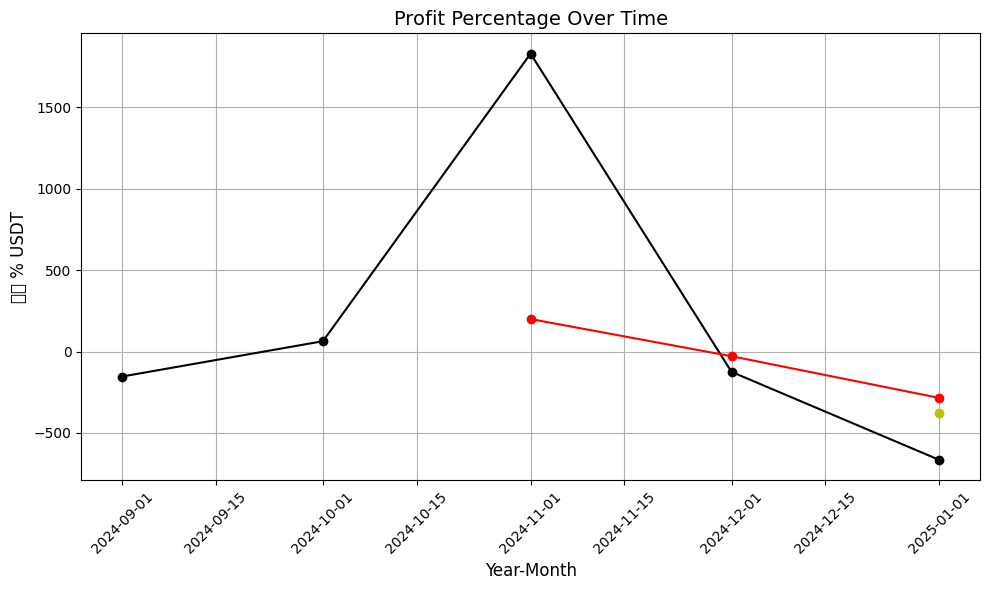

In [12]:
  calculate_profit1['Year-Month'] = pd.to_datetime(calculate_profit1[['Year', 'Month']].assign(DAY=1))
  calculate_profit2['Year-Month'] = pd.to_datetime(calculate_profit2[['Year', 'Month']].assign(DAY=1))
  calculate_profit3['Year-Month'] = pd.to_datetime(calculate_profit3[['Year', 'Month']].assign(DAY=1))
  # calculate_profit4['Year-Month'] = pd.to_datetime(calculate_profit4[['Year', 'Month']].assign(DAY=1))
  # calculate_profit5['Year-Month'] = pd.to_datetime(calculate_profit5[['Year', 'Month']].assign(DAY=1))
  # calculate_profit6['Year-Month'] = pd.to_datetime(calculate_profit6[['Year', 'Month']].assign(DAY=1))
  # calculate_profit7['Year-Month'] = pd.to_datetime(calculate_profit7[['Year', 'Month']].assign(DAY=1))
  # calculate_profit8['Year-Month'] = pd.to_datetime(calculate_profit8[['Year', 'Month']].assign(DAY=1))
  # calculate_profit9['Year-Month'] = pd.to_datetime(calculate_profit9[['Year', 'Month']].assign(DAY=1))
  # calculate_profit10['Year-Month'] = pd.to_datetime(calculate_profit10[['Year', 'Month']].assign(DAY=1))

  plt.figure(figsize=(10, 6))
  plt.plot(calculate_profit1['Year-Month'], calculate_profit1['Standalone Profit'], marker='o', linestyle='-', color='black')
  plt.plot(calculate_profit2['Year-Month'], calculate_profit2['Standalone Profit'], marker='o', linestyle='-', color='r')
  plt.plot(calculate_profit3['Year-Month'], calculate_profit3['Standalone Profit'], marker='o', linestyle='-', color='y')
  # plt.plot(calculate_profit4['Year-Month'], calculate_profit4['수익 % USDT'], marker='o', linestyle='-', color='black')
  # plt.plot(calculate_profit5['Year-Month'], calculate_profit5['수익 % USDT'], marker='o', linestyle='-', color='r')
  # # plt.plot(calculate_profit6['Year-Month'], calculate_profit6['수익 % USDT'], marker='o', linestyle='-', color='orange')
  # plt.plot(calculate_profit7['Year-Month'], calculate_profit7['수익 % USDT'], marker='o', linestyle='-', color='orange')
  # plt.plot(calculate_profit8['Year-Month'], calculate_profit8['수익 % USDT'], marker='o', linestyle='-', color='r')
  # plt.plot(calculate_profit9['Year-Month'], calculate_profit9['수익 % USDT'], marker='o', linestyle='-', color='b')
  # plt.plot(calculate_profit10['Year-Month'], calculate_profit10['수익 % USDT'], marker='o', linestyle='-', color='y')
  # Add titles and labels
  plt.title('Profit Percentage Over Time', fontsize=14)
  plt.xlabel('Year-Month', fontsize=12)
  plt.ylabel('수익 % USDT', fontsize=12)

  # Display the grid and the plot
  plt.grid(True)
  plt.xticks(rotation=45)
  plt.tight_layout()

  # Show the plot
  plt.show()

In [14]:
  def countPositiveAndNagetive(calculate_profit):
    positive_count = (calculate_profit['Standalone Profit %'] > 0).sum()
    negative_count = (calculate_profit['Standalone Profit %'] < 0).sum()

    positive = print('이익', positive_count)
    negative = print('손실', negative_count)

    return [positive, negative]

In [15]:
countPositiveAndNagetive(calculate_profit1)

이익 2
손실 3


[None, None]